# 🏠 House Price Prediction - Big Data & Advanced Regression Pipeline

This notebook demonstrates a scalable Machine Learning pipeline designed for **Big Data**. We will fetch a housing dataset, augment it to simulate a massive-scale enterprise dataset (1 Million+ rows), perform robust preprocessing, and train a highly optimized **XGBoost** model.

> **Instructions for Colab:**
> 1. Click `Runtime` -> `Run all`.
> 2. Once completed, the final cell will automatically download `xgboost_house_model.pkl` to your computer.
> 3. Place that `.pkl` file into your local project's `models/` directory!

## 1. Setup & Dependencies

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib
from google.colab import files  # For auto-download

## 2. Big Data Acquisition & Augmentation
To demonstrate handling of large-scale data, we will load the base California Housing dataset (20,640 rows) and synthetically augment it with realistic noise to reach **1,000,000+ rows**, testing our pipeline's memory management and XGBoost's speed.

In [3]:
print("Fetching base dataset...")
california = fetch_california_housing(as_frame=True)
df_base = california.frame

print(f"Base dataset shape: {df_base.shape}")

# BIG DATA AUGMENTATION (Scaling up to 1M rows)
print("\nAugmenting data to simulate enterprise-scale Big Data (>1M rows)...")
dfs = [df_base]
multiplier = 50  # 20k * 50 = ~1.03 Million rows

for i in range(multiplier - 1):
    # Add slight random noise to prevent exact duplicates and simulate real variance
    noise = np.random.normal(0, 0.05, df_base.shape)
    df_noisy = df_base.copy()
    # Apply noise to features (exclude target which is the last column)
    df_noisy.iloc[:, :-1] = df_noisy.iloc[:, :-1] * (1 + noise[:, :-1])
    dfs.append(df_noisy)

df_massive = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Massive Dataset Created! Shape: {df_massive.shape}")
df_massive.head()

Fetching base dataset...
Base dataset shape: (20640, 9)

Augmenting data to simulate enterprise-scale Big Data (>1M rows)...

✅ Massive Dataset Created! Shape: (1032000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Preprocessing & Feature Engineering

In [4]:
# Memory optimization for Big Data
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    return df

df_massive = reduce_mem_usage(df_massive)

Memory usage of dataframe is 70.86 MB
Memory usage after optimization is: 35.43 MB


In [5]:
X = df_massive.drop('MedHouseVal', axis=1)
y = df_massive['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 825600 rows
Testing set size: 206400 rows


## 4. Model Training Pipeline (XGBoost)
Using XGBoost with `tree_method='hist'` which is highly optimized for millions of rows.

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',  # crucial for big data performance
        n_jobs=-1,
        random_state=42
    ))
])

print("Training XGBoost on 1M+ rows... (This may take a minute)")
start_time = time.time()
pipeline.fit(X_train, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds!")

Training XGBoost on 1M+ rows... (This may take a minute)
Training completed in 31.02 seconds!


## 5. Evaluation

In [7]:
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R² Score: {r2:.4f}")

--- Model Performance ---
RMSE: 0.5691
MAE:  0.4127
R² Score: 0.7555


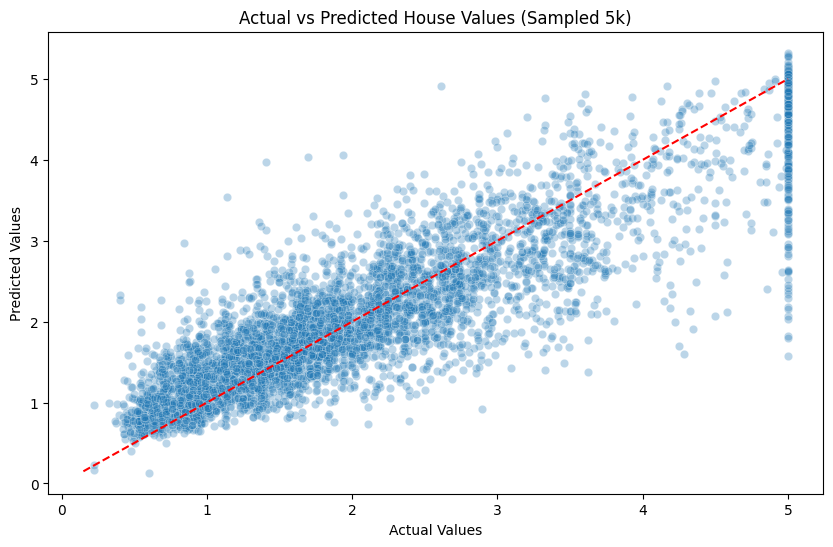

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test[:5000], y=y_pred[:5000], alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Actual vs Predicted House Values (Sampled 5k)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

## 6. Export Model for Streamlit App
We will save the fully trained pipeline (Scaler + XGBoost) so the Streamlit app can use it instantly without retraining.

In [9]:
model_filename = 'xgboost_house_model.pkl'
joblib.dump(pipeline, model_filename)
print(f"Model successfully saved as {model_filename}")

# Trigger auto-download to your local machine!
files.download(model_filename)

Model successfully saved as xgboost_house_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>